In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
titanic_df = pd.read_csv("../data/titanic.csv")

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic_df.shape

(891, 15)

In [4]:
titanic_df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [5]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [6]:
titanic_df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
titanic_df["age"] = (titanic_df["age"].fillna(titanic_df["age"].median()))

In [8]:
titanic_df["embarked"] = (titanic_df["embarked"].fillna(titanic_df["embarked"].mode()[0]))

In [9]:
titanic_df.drop(columns=["deck"],inplace=True)

In [10]:
titanic_df["embark_town"] = (titanic_df["embark_town"].fillna(titanic_df["embark_town"].mode()[0]))

In [11]:
titanic_df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [12]:
titanic_df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [13]:
titanic_df["survived"].value_counts(normalize = True) * 100

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

In [14]:
titanic_df["sex"] = titanic_df["sex"].map({"male":0,"female":1})

In [15]:
X = titanic_df[
    ["pclass", "sex", "age", "fare"]
]

y = titanic_df["survived"]

In [16]:
X.head()

,pclass,sex,age,fare
0,3,0,22.0,7.2500
1,1,1,38.0,71.2833
2,3,1,26.0,7.9250
3,1,1,35.0,53.1000
4,3,0,35.0,8.0500


In [17]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42
)

In [20]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (712, 4)
X_test : (179, 4)


In [21]:
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_train: (712,)
y_test : (179,)


In [22]:
titanic_df["age"].head()

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: age, dtype: float64

In [23]:
titanic_df["age"] = pd.to_numeric(titanic_df["age"],errors="coerce")

In [24]:
titanic_df["age"].dtype

dtype('float64')

In [25]:
titanic_df["age"].isnull().sum()

np.int64(0)

In [26]:
titanic_df["age"] = (titanic_df["age"].fillna(titanic_df["age"].median()))

In [27]:
from sklearn.linear_model import LogisticRegression


In [28]:

model = LogisticRegression()


In [29]:

model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
accuracy = accuracy_score(y_test,y_pred)

In [37]:
print("Accuracy:",accuracy * 100)

Accuracy: 80.44692737430168


In [38]:
from sklearn.metrics import confusion_matrix

In [39]:
cm = confusion_matrix(y_test,y_pred)

In [40]:
print(cm)

[[90 15]
 [20 54]]


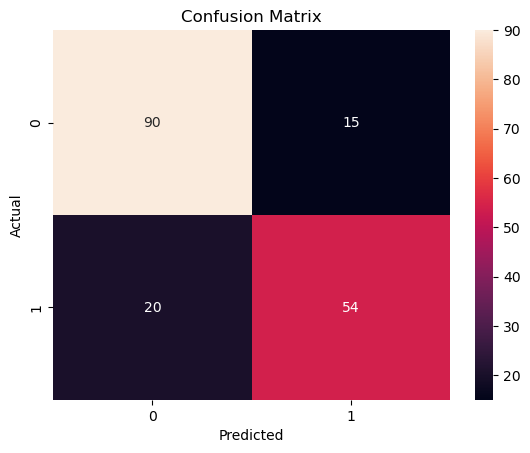

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

